## **3. Técnicas de Amostragem de Dados: Amostragem Estratificada**

#### Autor: Tony Esaú de Oliveira
Universidade Federal do Cariri - UFCA

#### **O que é amostragem?**

O processo de amostragem é formalmente definido como a seleção de um subconjunto (denominado amostra) de membros de uma população ou conjunto de dados original, com o propósito de derivar estimativas e tirar conclusões sobre essa população utilizando apenas os membros selecionados. Matematicamente, se $N$ representa o número total de elementos na população e $n$ o tamanho da amostra $S$, o processo seleciona elementos de tal forma que $n<N$

#### **Característica Essencial de uma Amostragem:**

Para que a amostragem seja válida, a amostra deve ser **representativa**, o que significa que ela deve conservar as características e propriedades consideradas importantes do conjunto original. Assim, os resultados obtidos pela análise da amostra devem ser muito semelhantes aos que seriam encontrados caso toda a população fosse processada


#### **Importância**

A importância da amostragem reside na viabilização da análise de dados em larga escala através de diversos benefícios:

- **Redução do Volume e Custo Computacional**: A mineração de dados e a análise de grandes volumes são processos caros e complexos. A amostragem funciona como uma técnica de redução de dados que permite que algoritmos operem de forma mais eficiente e rápida, diminuindo a complexidade de tempo;

- **Economia de Recursos**: Em muitas aplicações, coletar dados de toda uma população é irrealista ou impossível devido aos altos custos financeiros, de tempo, materiais e de mão de obra. A amostragem permite obter informações confiáveis com gastos significativamente menores;

- **Agilidade e Tempestividade**: Por ser um processo mais rápido, a amostragem permite que os resultados sejam publicados e utilizados de forma oportuna. Em ciência de dados, uma resposta aproximada e rápida é frequentemente preferível a uma resposta exata que demore muito tempo para ser processada;

- **Melhoria na Qualidade dos Dados**: Como o volume de dados a ser tratado é menor, os investigadores podem ser mais cuidadosos na coleta, treinamento e supervisão, o que muitas vezes resulta em dados mais precisos do que os obtidos em um censo completo, que pode estar sujeito a erros administrativos e de coleta em larga escala;

- **Necessidade Técnica**: Em casos onde a medição exige a destruição da unidade de observação (como testes de laboratório), a amostragem é o único meio de obter informações sem eliminar toda a população.

---

## Adult Census Income 

#### **Visão geral**

O dataset **Adult Census Income** é baseado em dados do censo dos Estados Unidos e tem como objetivo prever se a renda anual de uma pessoa excede **50 mil dólares**. É amplamente utilizado em aprendizado de máquina e análise estatística

#### **Estrutura dos dados**

* Total de instâncias: **32.561**
* Tarefa: **classificação binária**

#### **Atributos**

O dataset contém variáveis **categóricas e numéricas**:

##### *Numéricas*

`age`: idade;
* `fnlwgt`: peso amostral (importância da observação);
* `education-num`: nível de educação (numérico);
* `capital-gain`: ganhos de capital;
* `capital-loss`: perdas de capital;
* `hours-per-week`: horas trabalhadas por semana.

##### *Categóricas*

* `workclass`: tipo de emprego;
* `education`: nível de educação (texto);
* `marital-status`: estado civil;
* `occupation`: ocupação;
* `relationship`: relação familiar;
* `race`: raça;
* `sex`: gênero;
* `native-country`: país de origem;

#### **Variável alvo**

* `income`

  * `<=50K`
  * `>50K`

#### **Observações importantes**

* Alguns valores podem aparecer como `"?"` (dados faltantes simples);
* Mistura dados numéricos e categóricos;
* Representa um cenário **realista**, diferente de datasets artificiais.

---

In [32]:
import pandas as pd
import numpy as np

In [33]:
dados = pd.read_csv('Conjuntos_Dados/adult_census_income.csv')

In [34]:
dados.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [35]:
dados.shape

(32561, 15)

##### **Cálculo de Tamanho**

Para esse exemplo, iremos calcular o tamanho da amostra a partir do Intervalo de Confiança para Proporção:

$$\hat{p} \pm Z \cdot \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}}$$

Em que:

- $\hat{p}$: Proporção observada na amostra (estimativa da proporção real).

- $Z$: Valor crítico da distribuição normal padrão (depende do nível de confiança).

- $n$: Tamanho da amostra.

- $\hat{p}(1 - \hat{p})$: Variância da proporção.

- $\sqrt{\frac{\hat{p}(1 - \hat{p})}{n}}$: Erro padrão da proporção (mede a variabilidade da estimativa).

Vamos calcular considerando $99\%$ de confiança e erro menor igual a $2\%$. Para isso devemos garantir que o erro padrão de proporção seja menor ou igual a $2\%$. Para isso, consideremos o pior caso para o denominador $\hat{p}(1-\hat{p})$, isto é, quando ele é maximizado. Um estudo quadrático simples, nos apontará que esse valor é $0,5$. Vamos rearranjar a fórmula sabendo disso:

$$Z \cdot \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}} \leq 0,02$$
$$ \frac{1}{Z}Z \cdot \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}} \leq \frac{1}{Z} 0,02$$
$$\sqrt{\frac{\hat{p}(1 - \hat{p})}{n}} \leq \frac{0,02}{Z}$$
$$\frac{\sqrt{(0,5)^2}}{\sqrt{n}} \leq \frac{0,02}{Z}$$
$$\frac{0,5}{\sqrt{n}} \leq \frac{0,02}{Z}$$
$$\frac{\sqrt{n}} {0,5} \geq \frac{Z}{0,02}$$
$$ \sqrt{n} \geq \frac{Z}{0,02} \cdot 0,5$$
$$ n \geq (\frac{Z}{0,04})^2$$



Calculando:

In [36]:
from scipy.stats import norm
import math

Z = norm.ppf(0.99)

n = math.ceil((Z/0.04)**2)
n

3383

 #### **Amostragem Sistemática**

A Amostragem Estratificada é uma técnica onde uma população heterogênea é dividida em subgrupos mutuamente exclusivos e internamente homogêneos, chamados **estratos**.

Para realizar essa amostragem, seguimos estas propriedades:

- Partição da População: A população total $R$ de tamanho $N$ é dividida em $L$ estratos $(R_1​,R_2,…,R_L​)$, de modo que cada elemento pertença a apenas um grupo $(R_i​ \cap R_j​ = \varnothing$ e $\bigcup R_i ​= R)$.
- Seleção Independente: Uma amostra aleatória simples de tamanho $n_h$​ é extraída de cada estrato $h$ de forma independente.
- Estimador da Média: A média estratificada $(\overline{y}_{​str}​)$ é calculada como uma média ponderada das médias de cada estrato: 

$$\overline{y}_{str} = \sum_{h=1}^{L}\left(\frac{N_h}{N}\right)\overline{y}_h$$

Onde $N_h$​ é o tamanho do estrato na população e $\overline{y}_h$​ é a média observada na amostra desse estrato.

##### **Cálculo do Número de Estratos L**

O cálculo de $L$ depende de qual característica iremos utilizar. Algumas colunas de um Conjunto de Dados são separados em estratos por natureza, por exemplo, vejamos as colunas do `Adult Census Income`:

In [37]:
dados.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

As colunas `education` e `relationship`, por exemplo, são naturalmente estratificadas porque são categóricas. Entretanto, colunas como `age` e `capital.gain`, como são númericas, independente se são inteiras ou não, precisam ser divididas em intervalos. Colunas como `age` sendo dividida em intervalos de $20$ em $20$ anos $(0-20, 20-40, ...)$ podem não ser muito representativas. As melhores opções é utilizar os *quartis* ou observar a distribuição real. Vamos estratificar esse Conjunto de Dados por idade e raça, mas antes vamos ver as distribuições.

(array([2410., 3160., 2461., 3429., 3465., 2583., 3198., 2965., 1828.,
        2139., 1558., 1033.,  996.,  599.,  269.,  227.,  120.,   54.,
          20.,   47.]),
 array([17.  , 20.65, 24.3 , 27.95, 31.6 , 35.25, 38.9 , 42.55, 46.2 ,
        49.85, 53.5 , 57.15, 60.8 , 64.45, 68.1 , 71.75, 75.4 , 79.05,
        82.7 , 86.35, 90.  ]),
 <BarContainer object of 20 artists>)

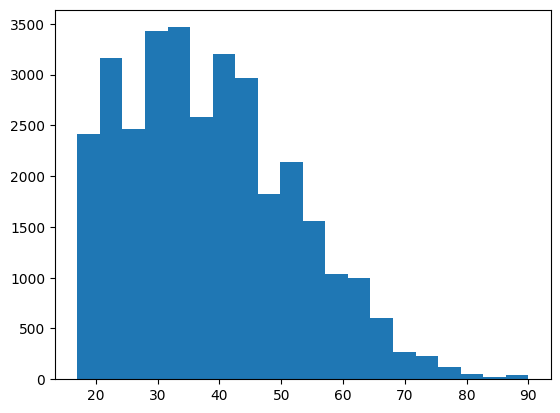

In [38]:
import matplotlib.pyplot as plt

plt.hist(dados['age'], bins=20)

In [39]:
dados['race'].value_counts()

race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64

#### **Amostragem Estratificada**

In [44]:
# Usamos pd.qcut para criar faixas de idade com a mesma quantidade de pessoas em cada faixa, ou seja, os quartis.
dados['faixa_idade'] = pd.qcut(dados['age'], q=4)
dados['faixa_idade'].value_counts()

faixa_idade
(16.999, 28.0]    8898
(37.0, 48.0]      8241
(28.0, 37.0]      7783
(48.0, 90.0]      7639
Name: count, dtype: int64

In [55]:
dados['estrato'] = dados['faixa_idade'].astype(str) + "_" + dados['race']
print(dados['estrato'].value_counts())
print(f"Número de estratos: {dados['estrato'].nunique()}")

estrato
(16.999, 28.0]_White                 7544
(37.0, 48.0]_White                   7008
(48.0, 90.0]_White                   6717
(28.0, 37.0]_White                   6547
(16.999, 28.0]_Black                  874
(37.0, 48.0]_Black                    828
(28.0, 37.0]_Black                    785
(48.0, 90.0]_Black                    637
(28.0, 37.0]_Asian-Pac-Islander       291
(16.999, 28.0]_Asian-Pac-Islander     281
(37.0, 48.0]_Asian-Pac-Islander       269
(48.0, 90.0]_Asian-Pac-Islander       198
(16.999, 28.0]_Other                  112
(28.0, 37.0]_Amer-Indian-Eskimo        87
(16.999, 28.0]_Amer-Indian-Eskimo      87
(37.0, 48.0]_Amer-Indian-Eskimo        82
(28.0, 37.0]_Other                     73
(48.0, 90.0]_Amer-Indian-Eskimo        55
(37.0, 48.0]_Other                     54
(48.0, 90.0]_Other                     32
Name: count, dtype: int64
Número de estratos: 20


Para saber o número de amostras que devem ser pegadas de cada estrato usamos a fórmula de alocação proporcional:

$$n_h ​= n \cdot \frac{N_h}{N}​$$

In [66]:
resultados = []

for estrato, count in dados['estrato'].value_counts().items():
    n_amostras = math.ceil((count / dados.shape[0]) * n)
    
    resultados.append({
        "estrato": estrato,
        "n_amostras": n_amostras
    })

resultados

[{'estrato': '(16.999, 28.0]_White', 'n_amostras': 784},
 {'estrato': '(37.0, 48.0]_White', 'n_amostras': 729},
 {'estrato': '(48.0, 90.0]_White', 'n_amostras': 698},
 {'estrato': '(28.0, 37.0]_White', 'n_amostras': 681},
 {'estrato': '(16.999, 28.0]_Black', 'n_amostras': 91},
 {'estrato': '(37.0, 48.0]_Black', 'n_amostras': 87},
 {'estrato': '(28.0, 37.0]_Black', 'n_amostras': 82},
 {'estrato': '(48.0, 90.0]_Black', 'n_amostras': 67},
 {'estrato': '(28.0, 37.0]_Asian-Pac-Islander', 'n_amostras': 31},
 {'estrato': '(16.999, 28.0]_Asian-Pac-Islander', 'n_amostras': 30},
 {'estrato': '(37.0, 48.0]_Asian-Pac-Islander', 'n_amostras': 28},
 {'estrato': '(48.0, 90.0]_Asian-Pac-Islander', 'n_amostras': 21},
 {'estrato': '(16.999, 28.0]_Other', 'n_amostras': 12},
 {'estrato': '(28.0, 37.0]_Amer-Indian-Eskimo', 'n_amostras': 10},
 {'estrato': '(16.999, 28.0]_Amer-Indian-Eskimo', 'n_amostras': 10},
 {'estrato': '(37.0, 48.0]_Amer-Indian-Eskimo', 'n_amostras': 9},
 {'estrato': '(28.0, 37.0]_Other

Essa abordagem é mais simples e se baseia na distribuição dos elementos na população. Outra técnica que poderia ser usada é a **distribuição de Neyman** que, ao invés de distribuir a amostra uniformemente entre os estratos, distribui proporcionalmente ao tamanho e à variabilidade de cada estrato.

$$n_h = n \cdot \frac{N_h \cdot \sigma_h}{\sum_{i=1}^{L} N_i \cdot \sigma_i}$$

Onde:

- $n_h =$ tamanho da amostra no estrato;
- $n =$ tamanho total da amostra;
- $N_h =$ tamanho do estrato na população;
- $\sigma_h =$ desvio padrão do estrato
- $L =$ número total de estratos.


In [67]:
soma = 0
for resultado in resultados:
    soma += resultado['n_amostras']
print(f"Total de amostras: {soma}")

Total de amostras: 3394


Agora basta construir a nossa amostra:

In [59]:
amostra_final = []

for resultado in resultados:
    estrato = resultado['estrato']
    n_amostras = resultado['n_amostras']
    
    amostra_estrato = dados[dados['estrato'] == estrato].sample(n=n_amostras, random_state=42)
    amostra_final.append(amostra_estrato)

amostra = pd.concat(amostra_final, ignore_index=True)
amostra

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,faixa_idade,estrato
0,21,Private,26410,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K,"(16.999, 28.0]","(16.999, 28.0]_White"
1,18,Private,376647,HS-grad,9,Never-married,Handlers-cleaners,Own-child,White,Male,2176,0,25,United-States,<=50K,"(16.999, 28.0]","(16.999, 28.0]_White"
2,20,Private,203027,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,55,United-States,<=50K,"(16.999, 28.0]","(16.999, 28.0]_White"
3,23,Private,380544,Some-college,10,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,>50K,"(16.999, 28.0]","(16.999, 28.0]_White"
4,19,?,241616,HS-grad,9,Never-married,?,Unmarried,White,Male,0,2001,40,United-States,<=50K,"(16.999, 28.0]","(16.999, 28.0]_White"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3389,38,?,94559,Bachelors,13,Married-civ-spouse,?,Wife,Other,Female,7688,0,50,?,>50K,"(37.0, 48.0]","(37.0, 48.0]_Other"
3390,50,Private,171852,Bachelors,13,Separated,Prof-specialty,Own-child,Other,Female,0,0,40,United-States,<=50K,"(48.0, 90.0]","(48.0, 90.0]_Other"
3391,52,Private,241444,1st-4th,2,Married-civ-spouse,Craft-repair,Husband,Other,Male,0,0,50,Puerto-Rico,<=50K,"(48.0, 90.0]","(48.0, 90.0]_Other"
3392,63,Private,440607,Preschool,1,Married-civ-spouse,Prof-specialty,Husband,Other,Male,0,0,30,Mexico,<=50K,"(48.0, 90.0]","(48.0, 90.0]_Other"


Comparando algumas proporções do Conjunto de Dados total e da amostra estratificada.

In [77]:
# Conjunto de Dados original.
print(dados['income'].value_counts(normalize=True))
print(dados['age'].mean())
print(dados['age'].std())
print(dados['race'].value_counts(normalize=True))
print(dados['workclass'].value_counts(normalize=True))


income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64
38.58164675532078
13.640432553581341
race
White                 0.854274
Black                 0.095943
Asian-Pac-Islander    0.031909
Amer-Indian-Eskimo    0.009551
Other                 0.008323
Name: proportion, dtype: float64
workclass
Private             0.697030
Self-emp-not-inc    0.078038
Local-gov           0.064279
?                   0.056386
State-gov           0.039864
Self-emp-inc        0.034274
Federal-gov         0.029483
Without-pay         0.000430
Never-worked        0.000215
Name: proportion, dtype: float64


In [78]:
# Amostra Estratificada.
print(amostra['income'].value_counts(normalize=True))
print(amostra['age'].mean())
print(amostra['age'].std())
print(amostra['race'].value_counts(normalize=True))
print(amostra['workclass'].value_counts(normalize=True))


income
<=50K    0.755451
>50K     0.244549
Name: proportion, dtype: float64
38.54095462581025
13.52755107803629
race
White                 0.852092
Black                 0.096346
Asian-Pac-Islander    0.032410
Amer-Indian-Eskimo    0.010312
Other                 0.008839
Name: proportion, dtype: float64
workclass
Private             0.708309
Self-emp-not-inc    0.076900
Local-gov           0.064526
?                   0.052445
Self-emp-inc        0.033589
State-gov           0.032410
Federal-gov         0.031821
Name: proportion, dtype: float64
